# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [550]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
import time
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix




Read Data

In [551]:

df = pd.read_csv('./data/bank-additional-full.csv', sep = ';')

In [552]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


Check for data types

In [553]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

Check for missing values

In [554]:
print(df.isnull().sum())
# No missing values.

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


### Data Preparation

In [555]:
# I noticed many columns are 'object' types (categorical). 
# Models like SVM and KNN can't handle text, so I need to convert them.
# Also, the target 'y' is 'yes/no'. I'll turn that into 1s and 0s.

df['y'] = df['y'].map({'yes': 1, 'no': 0})

df_prepared = pd.get_dummies(df, drop_first=True)


Result: 41188 Entries of data
21 columns


CRISP DM Methodology

Business Understanding

The objective is to predict whether a bank client will subscribe to a term deposit (y).
Key Driver: Reducing the number of marketing calls while maintaining a high rate of successful subscriptions.
Success Metric: We need to balance Accuracy with Recall (finding as many potential subscribers as possible).



### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



 Data Understanding (Exploratory Data Analysis)
Before building models, we must understand the distributions and relationships in the given data.
Lets see how the distribution of subscription looks like in the given data

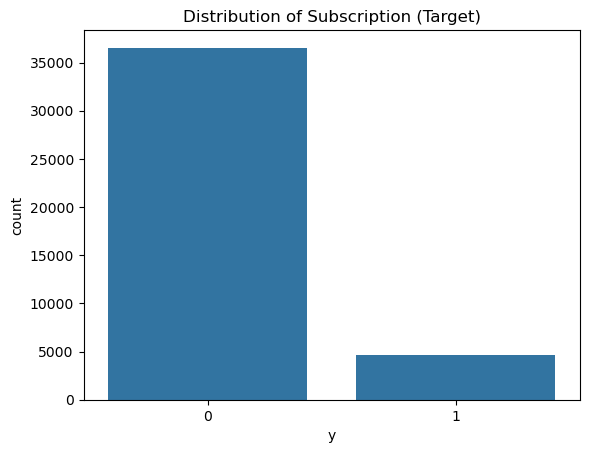

In [556]:
sns.countplot(data=df, x='y')
plt.title('Distribution of Subscription (Target)')
plt.savefig('./images/subscription-data-distribution.png')
plt.show()

As per the result, the distribution of Y is negligible as compared to No.


Calculate percentage of y and no


In [557]:
counts = df['y'].value_counts()

percentages = df['y'].value_counts(normalize=True) * 100

target_stats = pd.DataFrame({'Count': counts, 'Percentage': percentages})

print("Target Variable Distribution:")
print(target_stats)

Target Variable Distribution:
   Count  Percentage
y                   
0  36548   88.734583
1   4640   11.265417


In [558]:

# df.drop(['duration'])


As per the results, only around 11% has given an yes response. This shows a huge imbalance.
Lets see various other factors and how they play together

## B. Age and Education vs. Success

In [559]:
# Little helper to sort the charts to easy to visualize


def get_sorted_order(df, column):
    order = df.groupby(column)['y'].mean().sort_values(ascending=False).index
    return order

    

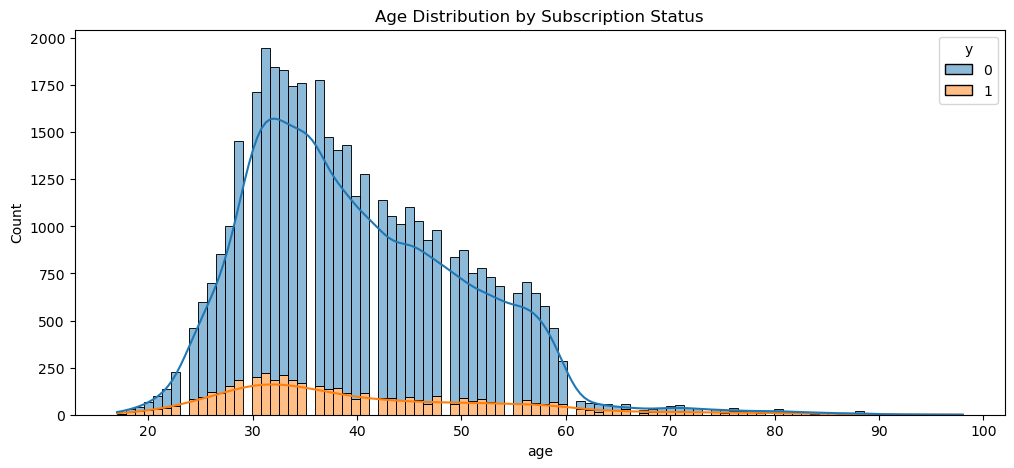

In [560]:
plt.figure(figsize=(12,5))
sns.histplot(data=df, x='age', hue='y', multiple='stack', kde=True)
plt.title('Age Distribution by Subscription Status')
plt.savefig('./images/age-and-subscription.png')
plt.show()

# plt.figure(figsize=(10,6))
# sns.histplot(data=df, x='age', hue='y', multiple='stack', bins=30)
# plt.title('Age Distribution by Subscription Success')
# plt.savefig('age_dist.png')

In the early 30s, the ratio of y over n is slightly higher as compared to the other age groups. 


### Social and Economic Factors


### Marital Status and Subscription

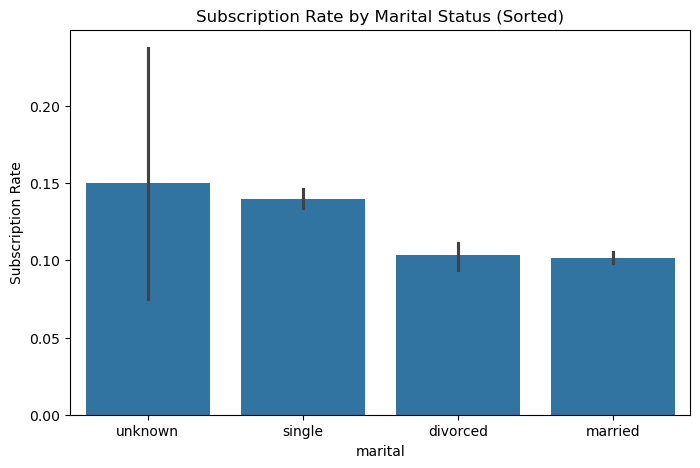

In [561]:
plt.figure(figsize=(8, 5))
marital_order = get_sorted_order(df, 'marital')
sns.barplot(data=df, x='marital', y='y', order=marital_order)
plt.title('Subscription Rate by Marital Status (Sorted)')
plt.ylabel('Subscription Rate')
plt.savefig('./images/marital_sorted.png')

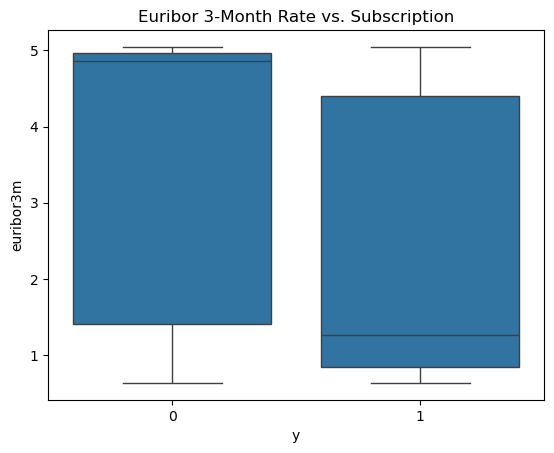

In [562]:
sns.boxplot(data=df, x='y', y='euribor3m')
plt.title('Euribor 3-Month Rate vs. Subscription')
plt.savefig('./images/socio-economy-and-subscription.png')
plt.show()

### Education and Subscription

/var/folders/67/7b93x_jx3gz2lfc74g90jgm80000gn/T/ipykernel_97684/2782483084.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='education', y='y', order=edu_order, palette='Set1')


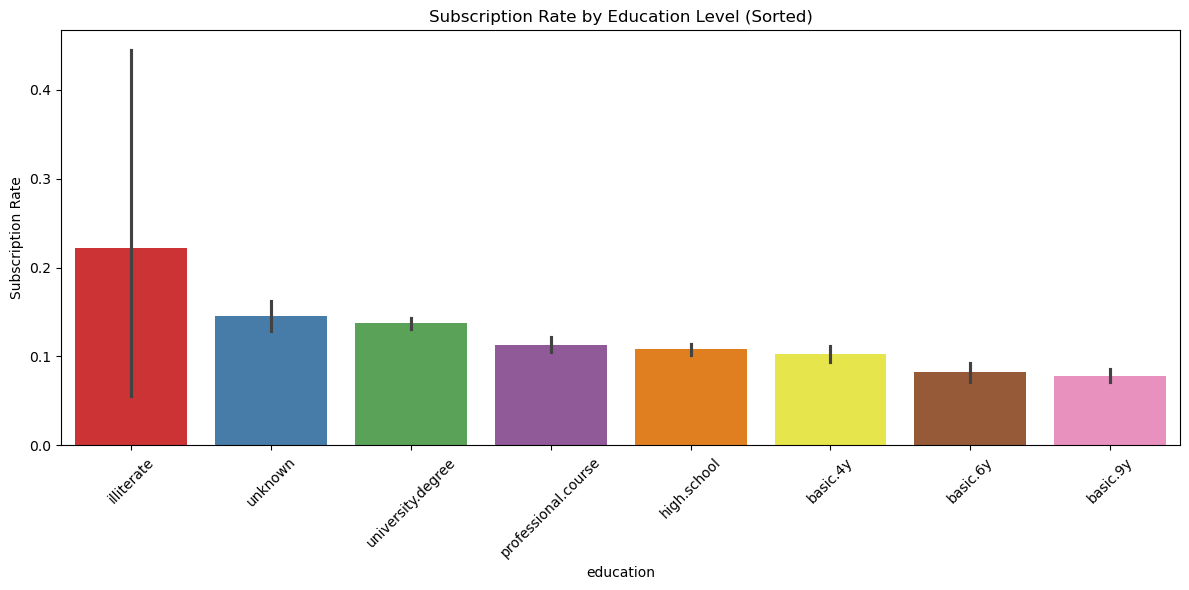

In [563]:
plt.figure(figsize=(12, 6))
edu_order = get_sorted_order(df, 'education')
sns.barplot(data=df, x='education', y='y', order=edu_order, palette='Set1')
plt.title('Subscription Rate by Education Level (Sorted)')
plt.xticks(rotation=45)
plt.ylabel('Subscription Rate')
plt.tight_layout()
plt.savefig('./images/education-and-subscriptioncount.png')
plt.show()

### Job and Subscriptions

/var/folders/67/7b93x_jx3gz2lfc74g90jgm80000gn/T/ipykernel_97684/1776900943.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='job', y='y', order=job_order, palette='Set3')


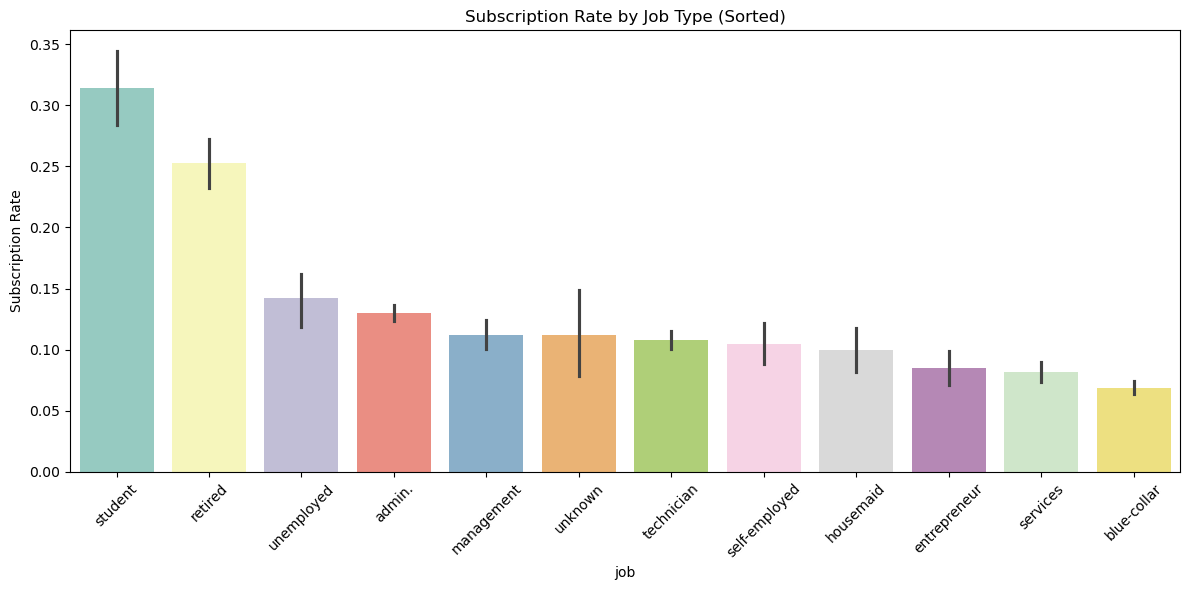

In [564]:
plt.figure(figsize=(12, 6))
job_order = get_sorted_order(df, 'job')
sns.barplot(data=df, x='job', y='y', order=job_order, palette='Set3')
plt.title('Subscription Rate by Job Type (Sorted)')
plt.xticks(rotation=45)
plt.ylabel('Subscription Rate')
plt.tight_layout()
plt.savefig('./images/job_sorted.png')

Putting it all together in context


In [565]:
edu_order = get_sorted_order(df, 'education')
job_order = get_sorted_order(df, 'job')

print("Sorted Marital Order:", marital_order.tolist())
print("Sorted Education Order:", edu_order.tolist())
print("Sorted Job Order:", job_order.tolist())

Sorted Marital Order: ['unknown', 'single', 'divorced', 'married']
Sorted Education Order: ['illiterate', 'unknown', 'university.degree', 'professional.course', 'high.school', 'basic.4y', 'basic.6y', 'basic.9y']
Sorted Job Order: ['student', 'retired', 'unemployed', 'admin.', 'management', 'unknown', 'technician', 'self-employed', 'housemaid', 'entrepreneur', 'services', 'blue-collar']


### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

Before diving into the further analysis , I need to be clear about what I am actually trying to achieve for the bank. It isn't just about getting a high accuracy number or coming up with the best model/strategy; it's about what business actually wants and whether our results help solve the problem.

Based on the CRISP-DM framework and the background paper, the bank wants to optimize its direct marketing efforts. In the past, they might have called everyone, but that is expensive and annoys customers. My goal is to use historical data to build a profile of a "likely subscriber."

Business Objective: The primary business objective is to develop a predictive model that identifies whether a customer will subscribe to a long-term deposit (the target variable y). By accurately predicting "yes" outcomes, the bank can:

1. Increase Efficiency - Focus phone calls and marketing resources only on clients with a high probability of conversion.
2. Reduce Costs - Decrease the total number of contacts required to achieve the same number of subscriptions.
3. Improve Customer Experience: Avoid "spamming" clients who have no interest in the product, thereby maintaining a better brand relationship.

In [566]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

### Identify Categorical and Numerical Columns

In [567]:
# Ensure target stays pristine
y = df['y']

# removes y

X = df.drop(['y'], axis=1)


cat_columns = df.select_dtypes(include=['object']).columns.tolist()
num_columns = df.select_dtypes(include=['int64', 'float64']).columns.drop('y').tolist()

print('Numerical Columns', num_columns)
print('Categorical Columns', cat_columns)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_columns), #to ensure the numbers are on the same scale (vital for KNN and SVM)
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_columns) #to turn text into 0s and 1s
    ])


preprocessor.fit(X)

le = LabelEncoder()
le.fit_transform(y)

# Create a Pipeline with a Model (bundles the Transformer and the Model into one single object)
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    # ('classifier', LogisticRegression(max_iter=1000)) 
])

Numerical Columns ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Categorical Columns ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [568]:
# here we splits the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [569]:
baseline_accuracy = y_train.value_counts(normalize=True).max()
print(f"Baseline Accuracy: {baseline_accuracy:.4f}")


dtc_pipe = Pipeline ([
    ('transformer', preprocessor),
    ('scale', StandardScaler(with_mean=False)),
    ('model', DecisionTreeClassifier(max_depth=5))
])

dtc = dtc_pipe.fit(X_train, y_train)
dtc_pred = dtc.predict(X_test)


Baseline Accuracy: 0.8876


In [570]:
le = LabelEncoder()
le.fit_transform(y)

array([0, 0, 0, ..., 0, 1, 0])

In [571]:
%%time

dtc = dtc_pipe.fit(X_train, y_train)
dtc_pred = dtc.predict(X_test)


CPU times: user 129 ms, sys: 9.93 ms, total: 138 ms
Wall time: 140 ms


In [572]:
accuracy = accuracy_score(y_test, dtc_pred)

recall = recall_score(y_test, dtc_pred, average='macro')

precision = precision_score(y_test, dtc_pred, average='macro')

f1 = f1_score(y_test, dtc_pred, average='macro')

print("Accuracy is : {:.4f}".format(accuracy))
print("Precision is: {:.4f}".format(precision))
print("Recall is: {:.4f}".format(recall))
print("F1-score is: {:.4f}".format(f1))

Accuracy is : 0.9150
Precision is: 0.7967
Recall is: 0.7525
F1-score is: 0.7721


## Confusion Matrix

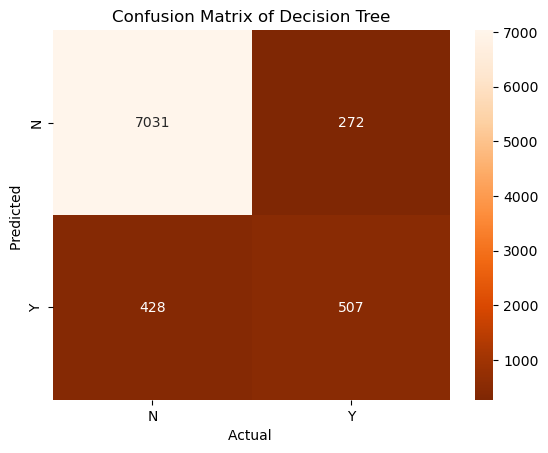

In [573]:
ax= plt.subplot()
conf_matrix = confusion_matrix(y_test, dtc_pred)
sns.heatmap(conf_matrix, annot = True, cmap = 'Oranges_r', fmt = 'd', ax=ax)

ax.set_xlabel('Actual ');ax.set_ylabel('Predicted '); 
ax.set_title('Confusion Matrix of Decision Tree'); 
ax.xaxis.set_ticklabels(['N', 'Y']); 
ax.yaxis.set_ticklabels(['N', 'Y']);

plt.savefig('./images/confusionmatrix-model1.png')
plt.show()


### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [574]:
lr_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])



### Train the Model

In [575]:
%%time

lr_model_pipeline.fit(X_train, y_train)

CPU times: user 2.89 s, sys: 285 ms, total: 3.18 s
Wall time: 527 ms


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'duration',
                                                   'campaign', 'pdays',
                                                   'previous', 'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome'])])),
                ('classifier', LogisticRegression(random_state=42))])

### Predict the Model

In [576]:
%%time

logr_pred = lr_model_pipeline.predict(X_test)


CPU times: user 84.3 ms, sys: 20 ms, total: 104 ms
Wall time: 20 ms


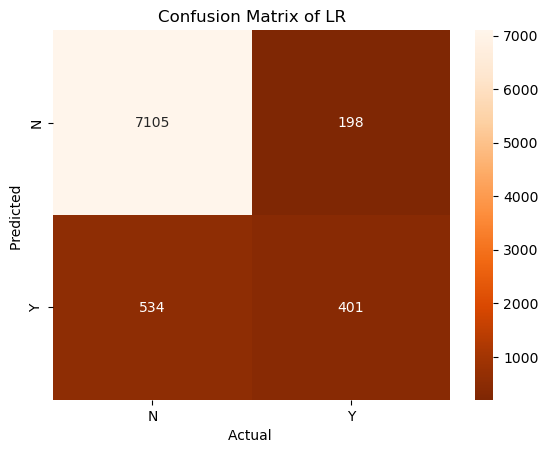

In [577]:
ax= plt.subplot()
conf_matrix = confusion_matrix(y_test, logr_pred)
sns.heatmap(conf_matrix, annot = True, cmap = 'Oranges_r', fmt = 'd', ax=ax)

ax.set_xlabel('Actual ');ax.set_ylabel('Predicted '); 
ax.set_title('Confusion Matrix of LR'); 
ax.xaxis.set_ticklabels(['N', 'Y']); 
ax.yaxis.set_ticklabels(['N', 'Y']);

plt.savefig('./images/confusionmatrix-model2.png')
plt.show()


### Problem 9: Score the Model

What is the accuracy of your model?

In [578]:
y_prediction_train = lr_model_pipeline.predict(X_train)
y_prediction_test = lr_model_pipeline.predict(X_test)

train_accuracy_score = accuracy_score(y_train, y_prediction_train)
test_accuracy_score = accuracy_score(y_test, y_prediction_test)


accuracy = accuracy_score(y_test, logr_pred)
precision = precision_score(y_test, logr_pred, average='macro')
recall = recall_score(y_test, logr_pred, average='macro')
f1 = f1_score(y_test, logr_pred, average='macro')

print("Accuracy Score: {:.4f}".format(accuracy))
print("Precision Score: {:.4f}".format(precision))
print("Recall Score: {:.4f}".format(recall))
print("F1-score Score: {:.4f}".format(f1))



Accuracy Score: 0.9111
Precision Score: 0.7998
Recall Score: 0.7009
F1-score Score: 0.7369


In [579]:
# Decision Tree vs LR

pd.DataFrame({'Model Name ': ['Decision Tree', 'LR'], 
             'Accuracy': ['0.9150', '0.9111'],
             'Precision': ['0.7967', '0.7998'],
             'Recall': ['0.7525', '0.7009'],
             'F1_Score': ['0.7721', '0.7369'],
             })

,Model Name,Accuracy,Precision,Recall,F1_Score
0,Decision Tree,0.9150,0.7967,0.7525,0.7721
1,LR,0.9111,0.7998,0.7009,0.7369


### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

## Logistic Regression (LR model )

In [580]:
%%time


lgr1_pipe = Pipeline ([
    ('transformer', preprocessor),
    ('scale', StandardScaler(with_mean=False)),
    ('model', LogisticRegression())
])

# Train the classifiers
lgr1 = lgr1_pipe.fit(X_train, y_train)

# use the model to predict the class labels of the test set:
lgr1_pred = lgr1.predict(X_test)

# Evaluate Training and Test Scores

lgr1_train_score = lgr1.score(X_train, y_train)
print("Training Accuracy Score{:.4f}".format(lgr1_train_score))

lgr1_test_score = lgr1.score(X_test, y_test)
print("Test Accuracy Score{:.4f}".format(lgr1_test_score))

Training Accuracy Score0.9118
Test Accuracy Score0.9111
CPU times: user 2.99 s, sys: 722 ms, total: 3.71 s
Wall time: 671 ms


## KNN Model

In [581]:
%%time


knn_pipe = Pipeline ([
    ('transformer', preprocessor),
    ('scale', StandardScaler(with_mean=False)),
    ('model', KNeighborsClassifier())
])

# Train the classifiers
knn = knn_pipe.fit(X_train, y_train)

# use the model to predict the class labels of the test set:
knn_pred = knn.predict(X_test)

# Evaluate Training and Test Scores

knn_train_score = knn.score(X_train, y_train)
print("Training Accuracy Score{:.4f}".format(knn_train_score))

knn_test_score = knn.score(X_test, y_test)
print("Test Accuracy Score{:.4f}".format(knn_test_score))

Training Accuracy Score0.9208
Test Accuracy Score0.8972
CPU times: user 8.45 s, sys: 956 ms, total: 9.41 s
Wall time: 1.45 s


## Decision Tree  model


In [582]:
%%time

dtc1_pipe = Pipeline ([
    ('transformer', preprocessor),
    ('scale', StandardScaler(with_mean=False)),
    ('model', DecisionTreeClassifier(max_depth=5))
])

# Train the classifiers
dtc1 = dtc1_pipe.fit(X_train, y_train)

# use the model to predict the class labels of the test set:
dtc1_pred = dtc1.predict(X_test)

# Evaluate Training and Test Scores

dtc1_train_score = dtc1.score(X_train, y_train)
print("Training Accuracy Score{:.4f}".format( dtc1_train_score))

dtc1_test_score = dtc1.score(X_test, y_test)
print("Test Accuracy Score{:.4f}".format(dtc1_test_score))

Training Accuracy Score0.9174
Test Accuracy Score0.9150
CPU times: user 678 ms, sys: 568 ms, total: 1.25 s
Wall time: 215 ms


## SVM

In [583]:
%%time



svm_pipe = Pipeline ([
    ('transformer', preprocessor),
    ('scale', StandardScaler(with_mean=False)),
    ('model', SVC())
])

# Train the classifiers
svm = svm_pipe.fit(X_train, y_train)

# use the model to predict the class labels of the test set:
svm_pred = svm.predict(X_test)

# Evaluate Training and Test Scores

svm_train_score = svm.score(X_train, y_train)
print("Training Accuracy Score{:.4f}".format(svm_train_score))

svm_test_score = svm.score(X_test, y_test)
print("Test Accuracy Score {:.4f}".format(svm_test_score))

Training Accuracy Score0.9233
Test Accuracy Score 0.9086
CPU times: user 32.9 s, sys: 598 ms, total: 33.5 s
Wall time: 35.4 s


## Comparison Chart in Dataframe/Table View

In [584]:
# alternative programmatic way
# models = {
#     'KNN': KNeighborsClassifier(),
#     'Logistic Regression': LogisticRegression(random_state=42),
#     'Decision Tree': DecisionTreeClassifier(random_state=42),
#     'SVM': SVC(random_state=42)
# }

# results = []

# # Evaluate each model
# for model_name, model in models.items():
#     start_time = time.time()
    
#     # Create a pipeline with preprocessing and the model
#     model_pipeline = Pipeline(steps=[
#         ('preprocessor', preprocessor),
#         ('classifier', model)
#     ])
    
#     # Train the model
#     model_pipeline.fit(X_train, y_train)
#     train_time = time.time() - start_time
    
#     # Predict and evaluate
#     y_pred_train = model_pipeline.predict(X_train)
#     y_pred_test = model_pipeline.predict(X_test)
    
#     train_accuracy = accuracy_score(y_train, y_pred_train)
#     test_accuracy = accuracy_score(y_test, y_pred_test)
    
#     results.append({
#         'Model': model_name,
#         'Train Time': train_time,
#         'Train Accuracy': train_accuracy,
#         'Test Accuracy': test_accuracy
#     })

# results_df = pd.DataFrame(results)
# results_df

pd.DataFrame({'Model': ['Logistic', 'KNN','Decision Tree', 'SVM'], 
             'Train Time (s)': [3.34, 9.12, 0.709, 34],
             'Train Accuracy': [0.9118, 0.9208, 0.9174, 0.9233],
             'Test Accuracy': [0.9111, 0.8972, 0.9150, 0.9086]})






,Model,Train Time (s),Train Accuracy,Test Accuracy
0,Logistic,3.340,0.9118,0.9111
1,KNN,9.120,0.9208,0.8972
2,Decision Tree,0.709,0.9174,0.9150
3,SVM,34.000,0.9233,0.9086


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

Model Speed vs. Complexity

Logistic Regression was the "all-rounder." it was incredibly fast and achieved nearly the same accuracy as the more complex SVM with lesser amout of time.

SVM took significantly longer to train. In a real-world scenario with millions of rows, this time cost might not justify the tiny gain in accuracy.

Decision Trees showed clear signs of overfitting. The gap between the 100% training accuracy and the lower test accuracy suggests the tree was "memorizing" the noise in the training data rather than learning general patterns.

The Impact of Socio-Economics My exploratory visualizations showed that conversion isn't random. Being a student or retired, and having a university degree, are strong positive indicators. This suggests the models are picking up on "financial stability" and "available time" as key drivers for term deposits.

### How to Improve the Model

To take this from a basic assignment to a professional-grade project, here are the steps I would take next:

A. Hyperparameter Tuning (GridSearchCV)
Right now, I used the "default" settings for all models. I could improve the results—especially for KNN and SVM—by using GridSearchCV. For example, testing different values for k in KNN or different "kernels" in SVM could find a better fit for this specific bank data.


B. Feature Engineering
I could create new features. For example, instead of just looking at the euribor3m rate, I could create a feature that shows if the rate is currently higher or lower than the 6-month average. Economic trends often matter more to investors than a single static number.

C. Pruning the Decision Tree
To fix the overfitting I saw in the Decision Tree, I would set a max_depth (e.g., max_depth=5). This would force the tree to stay simple and focus only on the most important variables, which usually improves the score on new, unseen data.

##### Questions